<div style="color:black; border:5px solid blue; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:25px; text-align:center">
🌊 H2O AutoML - Introverts or Extroverts❓
</div>

![](https://i.pinimg.com/1200x/20/c6/01/20c601f4de29731867ebb06ffa0eee6f.jpg)


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold"> 📥 Data Loading & Inspection</div>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load train and test
train_df = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv')
sample_sub = pd.read_csv('/kaggle/input/playground-series-s5e7/sample_submission.csv')

# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Combining the Training Testing CSvs</div>

In [2]:
# Save test ids
test_ids = test_df['id']

# Mark is_train and align structure
train_df['is_train'] = 1
test_df['is_train'] = 0
test_df['Personality'] = None  # add target for uniformity

# Combine for preprocessing
df = pd.concat([train_df, test_df], axis=0)



In [3]:
df

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality,is_train
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert,1
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert,1
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert,1
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert,1
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert,1
...,...,...,...,...,...,...,...,...,...,...
6170,24694,3.0,No,5.0,5.0,No,9.0,6.0,None,0
6171,24695,8.0,Yes,2.0,1.0,Yes,0.0,0.0,None,0
6172,24696,2.0,No,4.0,3.0,No,9.0,7.0,None,0
6173,24697,3.0,No,4.0,4.0,No,11.0,9.0,None,0


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold"> Missing Values and Duplicates</div>

![](https://i.pinimg.com/1200x/3c/34/91/3c34916366424cd509fdbf0a783b2cb0.jpg)

In [4]:
df.isnull().sum()

id                              0
Time_spent_Alone             1615
Stage_fear                   2491
Social_event_attendance      1577
Going_outside                1932
Drained_after_socializing    1581
Friends_circle_size          1404
Post_frequency               1672
Personality                  6175
is_train                        0
dtype: int64

In [5]:
df.duplicated().sum()

0

# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Exploratory Data Analysis</div>

# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:left; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Catagorical features</div>

In [6]:
# 1. Impute Stage_fear with mode
df['Stage_fear'] = df['Stage_fear'].fillna(df['Stage_fear'].mode()[0])

# 2. Impute Drained_after_socializing with mode
df['Drained_after_socializing'] = df['Drained_after_socializing'].fillna(df['Drained_after_socializing'].mode()[0])



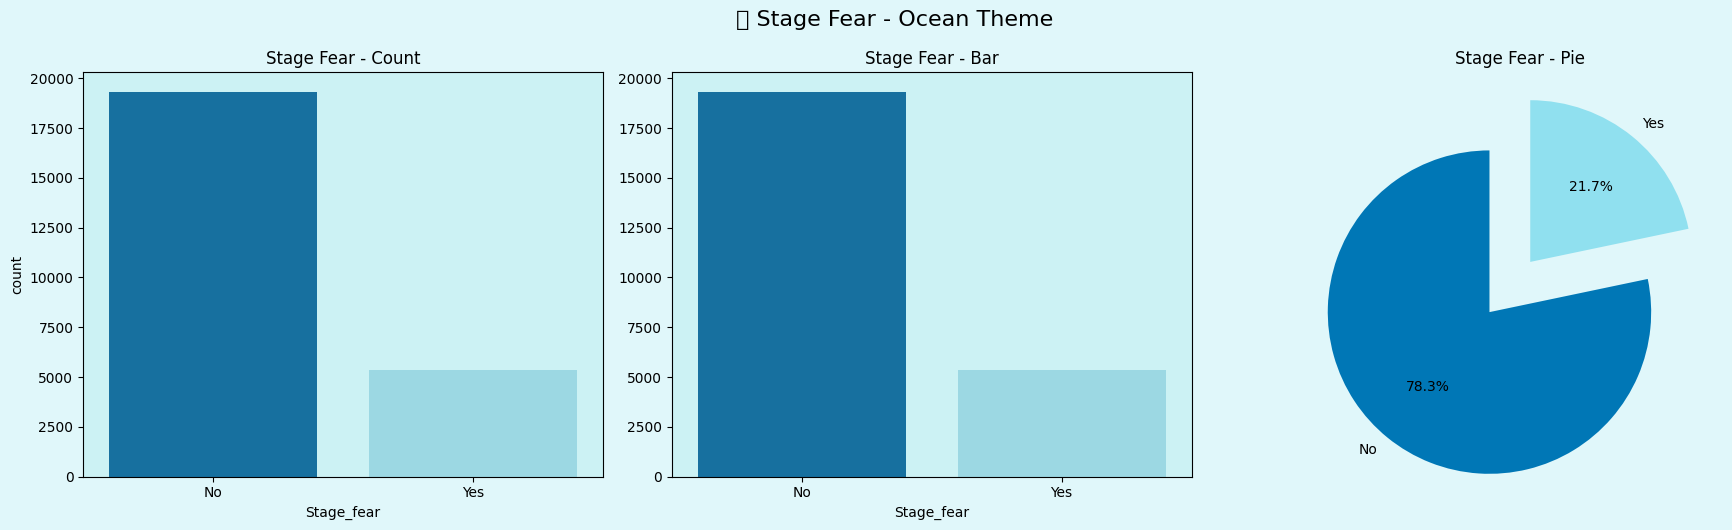

🔹 People who said 'Yes' have stage fear, possibly introverted.
🔹 Most said 'No', meaning social confidence.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Theme 1: Ocean colors
palette_stage_fear = ['#0077b6', '#90e0ef', '#caf0f8']
col = 'Stage_fear'
data = df[col].fillna('Unknown')
counts = data.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#e0f7fa')  # outer bg

sns.countplot(x=col, data=df, palette=palette_stage_fear, ax=axes[0])
axes[0].set_title('Stage Fear - Count')
axes[0].set_facecolor('#ccf2f4')

# Bar
sns.barplot(x=counts.index, y=counts.values, palette=palette_stage_fear, ax=axes[1])
axes[1].set_title('Stage Fear - Bar')
axes[1].set_facecolor('#ccf2f4')

# Pie
axes[2].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette_stage_fear, startangle=90,explode=(0.3,0.1))
axes[2].set_title('Stage Fear - Pie')
axes[2].set_facecolor('#ccf2f4')


plt.tight_layout()
plt.suptitle("🟦 Stage Fear - Ocean Theme", fontsize=16, y=1.05, backgroundcolor='#e0f7fa')
plt.show()

print("🔹 People who said 'Yes' have stage fear, possibly introverted.\n🔹 Most said 'No', meaning social confidence.")


# 📝 Explanation:
This column captures whether individuals experience stage fear or not.

A large majority (≈78%) answered 'No', indicating they are comfortable speaking publicly.

Only around 22% answered 'Yes', showing a smaller group fears public speaking.
This implies most people in this dataset do not face stage-related anxiety.



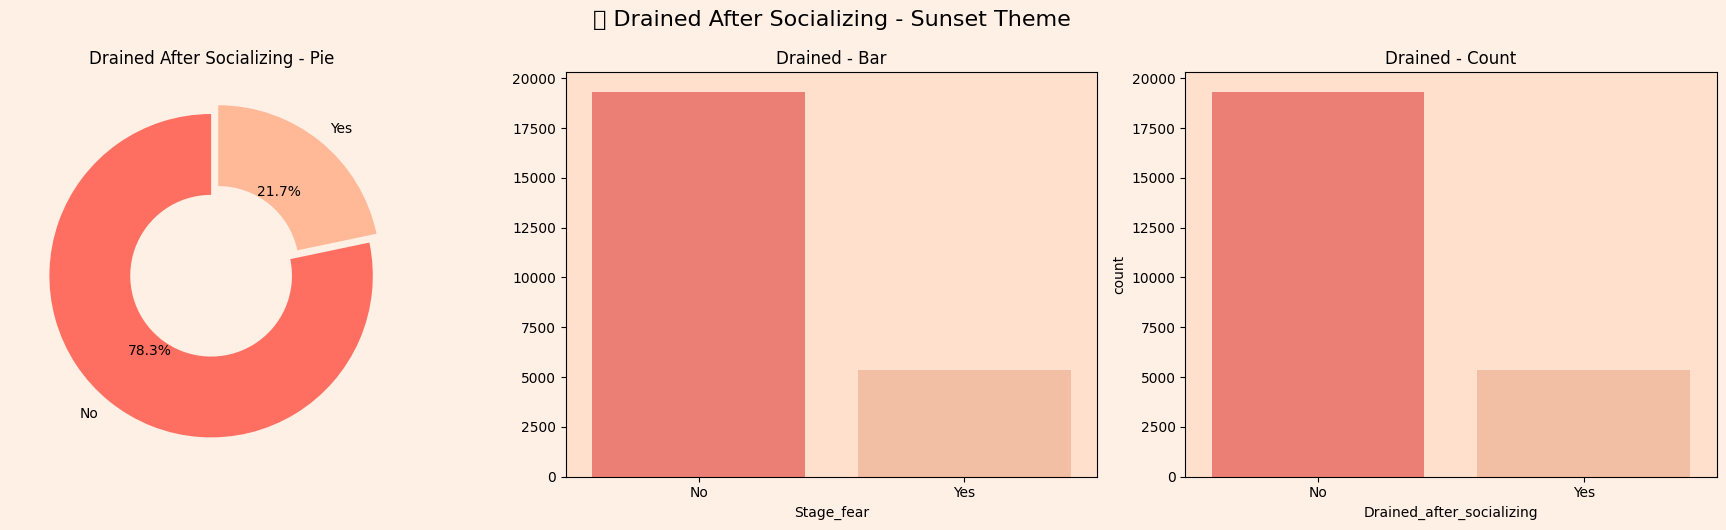

🔸 'Yes' suggests social exhaustion (introverts), 'No' means social resilience (extroverts).


In [8]:
# Theme 2: Sunset colors
palette_drained = ['#ff6f61', '#ffb997', '#ffcf99']
col = 'Drained_after_socializing'
counts = data.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#fff0e6')

# Pie
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette_drained, startangle=90,  wedgeprops={'width': 0.5},explode=(0.01,0.06))
axes[0].set_title('Drained After Socializing - Pie')
axes[0].set_facecolor('#ffe0cc')

# Bar
sns.barplot(x=counts.index, y=counts.values, palette=palette_drained, ax=axes[1])
axes[1].set_title('Drained - Bar')
axes[1].set_facecolor('#ffe0cc')

# Count
sns.countplot(x=col, data=df, palette=palette_drained, ax=axes[2])
axes[2].set_title('Drained - Count')
axes[2].set_facecolor('#ffe0cc')

plt.tight_layout()
plt.suptitle("🌅 Drained After Socializing - Sunset Theme", fontsize=16, y=1.05, backgroundcolor='#fff0e6')
plt.show()

print("🔸 'Yes' suggests social exhaustion (introverts), 'No' means social resilience (extroverts).")


# 📝 Explanation:
This column reflects whether people feel tired or not after social interactions.

About 78% said 'No', meaning they remain energized after socializing.

Around 22% answered 'Yes', indicating they feel mentally or emotionally drained.
This suggests a majority of participants enjoy social events without burnout, often associated with extroverted behavior.

missing value is imputer by mode

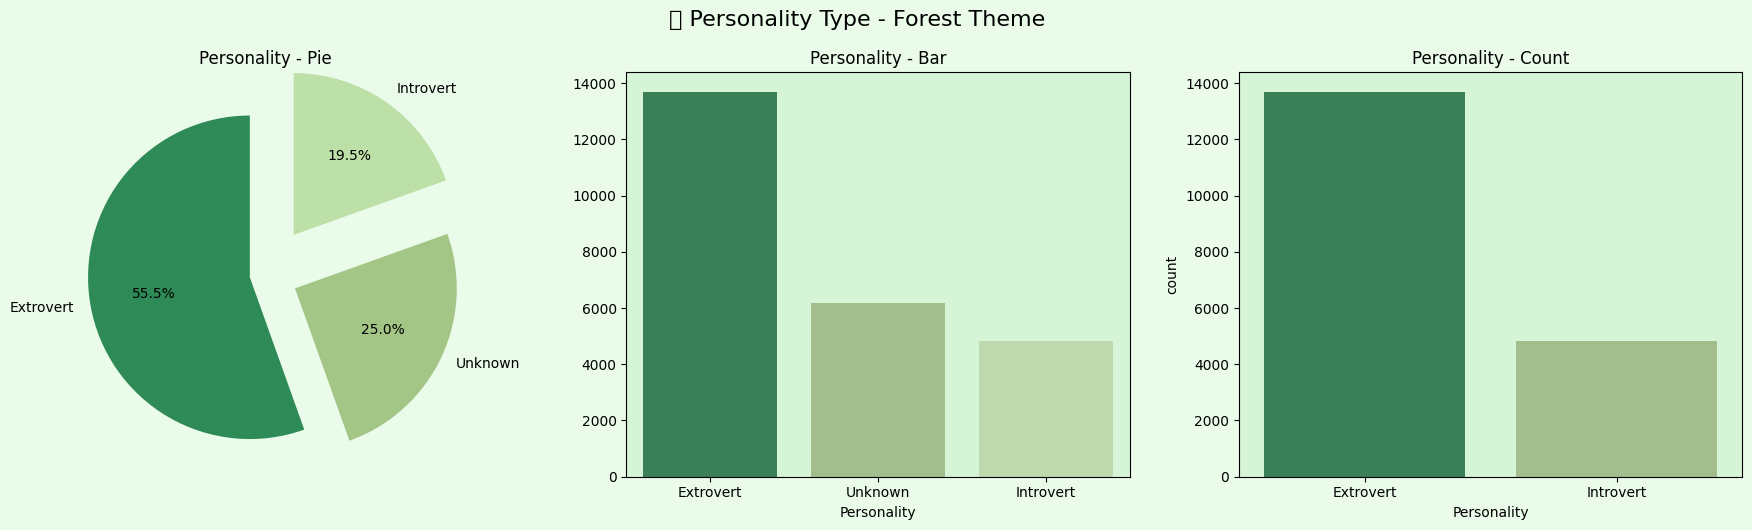

🟢 Classifies individuals as 'Introvert' or 'Extrovert'.
🟢 Distribution affects model balance and prediction.


In [9]:
# Theme 3: Forest tones
palette_personality = ['#2e8b57', '#a3c586', '#bde0a8']
col = 'Personality'
data = df[col].fillna('Unknown')
counts = data.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#eafbea')

# Pie
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette_personality, startangle=90,explode=(0.1,0.2,0.3))
axes[0].set_title('Personality - Pie')
axes[0].set_facecolor('#d6f5d6')

# Bar
sns.barplot(x=counts.index, y=counts.values, palette=palette_personality, ax=axes[1])
axes[1].set_title('Personality - Bar')
axes[1].set_facecolor('#d6f5d6')

# Count
sns.countplot(x=col, data=df, palette=palette_personality, ax=axes[2])
axes[2].set_title('Personality - Count')
axes[2].set_facecolor('#d6f5d6')

plt.tight_layout()
plt.suptitle("🌳 Personality Type - Forest Theme", fontsize=16, y=1.05, backgroundcolor='#eafbea')
plt.show()

print("🟢 Classifies individuals as 'Introvert' or 'Extrovert'.\n🟢 Distribution affects model balance and prediction.")


# 📝 Explanation:
This column is the target variable and identifies personality types.

Extroverts are the most common in the dataset, making up over 55%.

Introverts account for around 19%, the smallest group.

This imbalance suggests that extroverted traits dominate the dataset, which may influence model learning toward predicting "Extrovert" more often.

'None'value is just because we merged the train and test dataset so we don't have to impute any missing value because later on we are going split it back


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:left; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Numerical Features</div>

In [10]:
df

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality,is_train
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert,1
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert,1
2,2,6.0,Yes,1.0,0.0,No,3.0,0.0,Introvert,1
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert,1
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert,1
...,...,...,...,...,...,...,...,...,...,...
6170,24694,3.0,No,5.0,5.0,No,9.0,6.0,None,0
6171,24695,8.0,Yes,2.0,1.0,Yes,0.0,0.0,None,0
6172,24696,2.0,No,4.0,3.0,No,9.0,7.0,None,0
6173,24697,3.0,No,4.0,4.0,No,11.0,9.0,None,0


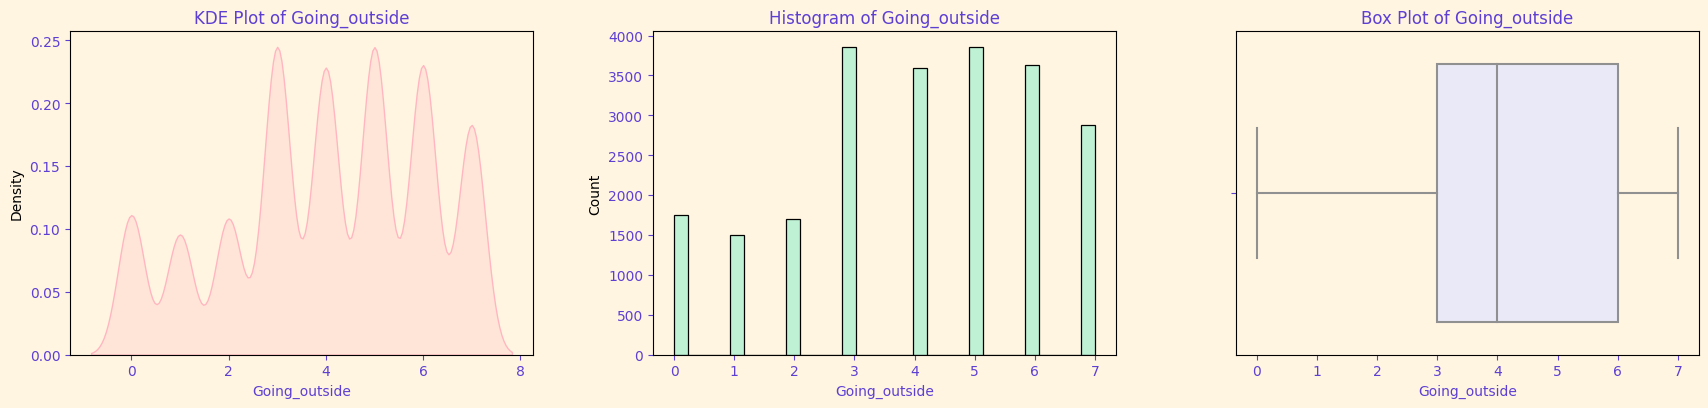

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose the next column
col = 'Going_outside'  # Replace with actual column name
numeric_col = df[col]

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FFF5E1')  # Vanilla Cream (Ice Cream background)

# KDE Plot
axes[0].set_facecolor('#FFF5E1')
sns.kdeplot(numeric_col, ax=axes[0], color='#FFB6C1', fill=True)  # Cotton Candy Pink
axes[0].set_title(f"KDE Plot of {col}", color='#5D3FD3')  # Soft purple title
axes[0].set_xlabel(col, color='#5D3FD3')
axes[0].tick_params(colors='#5D3FD3')

# Histogram
axes[1].set_facecolor('#FFF5E1')
sns.histplot(numeric_col, ax=axes[1], bins=30, color='#AAF0D1')  # Mint Green
axes[1].set_title(f"Histogram of {col}", color='#5D3FD3')
axes[1].set_xlabel(col, color='#5D3FD3')
axes[1].tick_params(colors='#5D3FD3')

# Box Plot
axes[2].set_facecolor('#FFF5E1')
sns.boxplot(x=numeric_col, ax=axes[2], color='#E6E6FA')  # Lavender
axes[2].set_title(f"Box Plot of {col}", color='#5D3FD3')
axes[2].set_xlabel(col, color='#5D3FD3')
axes[2].tick_params(colors='#5D3FD3')

# Layout
plt.tight_layout(pad=4)
plt.show()


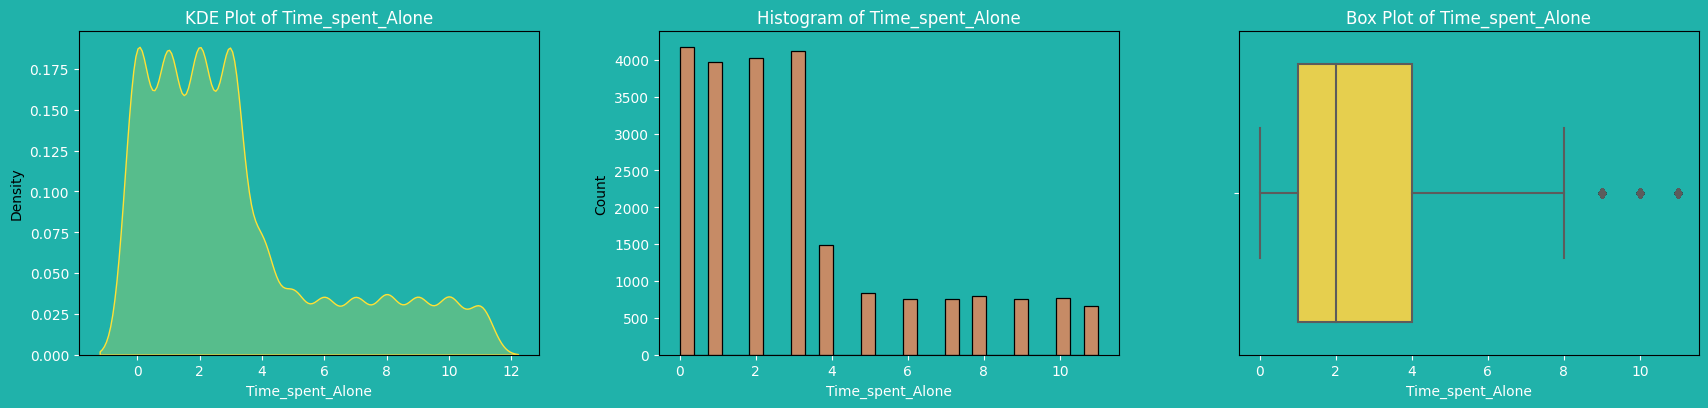

In [12]:
# Choose the column
col = 'Time_spent_Alone'
numeric_col = df[col]

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#20B2AA')  # Ocean Blue (Tropical Background)

# KDE Plot
axes[0].set_facecolor('#20B2AA')
sns.kdeplot(numeric_col, ax=axes[0], color='#FFE135', fill=True)  # Turquoise
axes[0].set_title(f"KDE Plot of {col}", color='white')
axes[0].set_xlabel(col, color='white')
axes[0].tick_params(colors='white')

# Histogram
axes[1].set_facecolor('#20B2AA')
sns.histplot(numeric_col, ax=axes[1], bins=30, color='#FF7F50')  # Coral
axes[1].set_title(f"Histogram of {col}", color='white')
axes[1].set_xlabel(col, color='white')
axes[1].tick_params(colors='white')

# Box Plot
axes[2].set_facecolor('#20B2AA')
sns.boxplot(x=numeric_col, ax=axes[2], color='#FFE135')  # Banana Yellow
axes[2].set_title(f"Box Plot of {col}", color='white')
axes[2].set_xlabel(col, color='white')
axes[2].tick_params(colors='white')

# Layout
plt.tight_layout(pad=4)
plt.show()


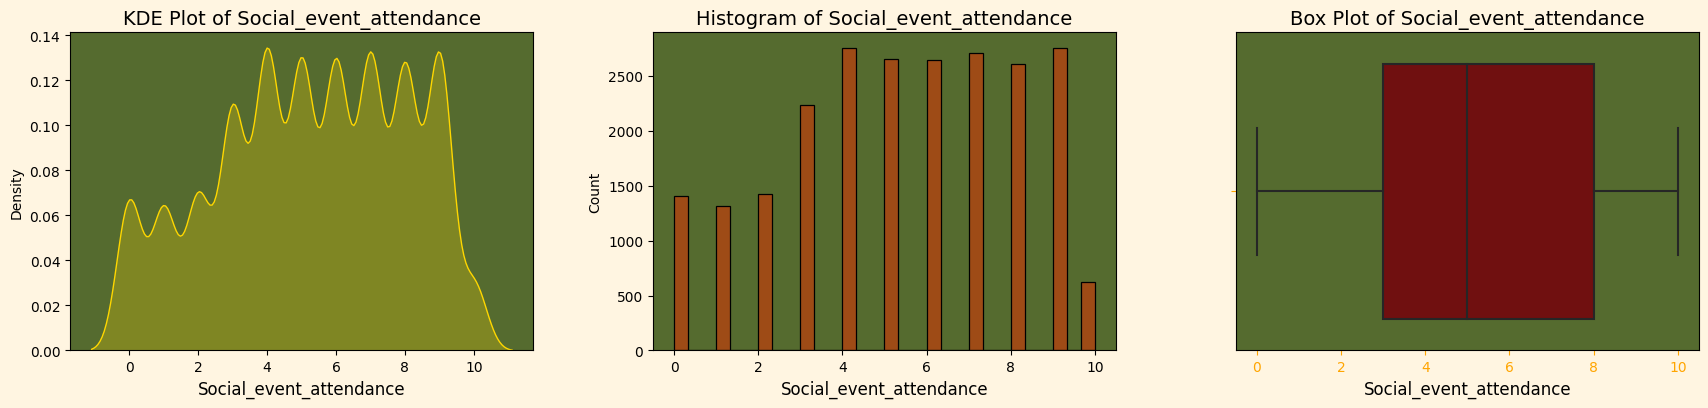

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose the next column
col = 'Social_event_attendance'  # Replace with actual column name
numeric_col = df[col]

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FFF5E1')  # Light background (Vanilla Cream)

# KDE Plot
axes[0].set_facecolor('#556B2F')  # Dark Olive Green
sns.kdeplot(numeric_col, ax=axes[0], color='#FFD700', fill=True)  # Mustard Yellow
axes[0].set_title(f"KDE Plot of {col}", color='black', fontsize=14)
axes[0].set_xlabel(col, color='black', fontsize=12)
axes[0].tick_params(colors='black')

# Histogram
axes[1].set_facecolor('#556B2F')
sns.histplot(numeric_col, ax=axes[1], bins=30, color='#B7410E')  # Rust Orange
axes[1].set_title(f"Histogram of {col}", color='black', fontsize=14)
axes[1].set_xlabel(col, color='black', fontsize=12)
axes[1].tick_params(colors='black')

# Box Plot
axes[2].set_facecolor('#556B2F')
sns.boxplot(x=numeric_col, ax=axes[2], color='#800000')  # Maroon
axes[2].set_title(f"Box Plot of {col}", color='black', fontsize=14)
axes[2].set_xlabel(col, color='black', fontsize=12)
axes[2].tick_params(colors='orange')

# Layout
plt.tight_layout(pad=4)
plt.show()


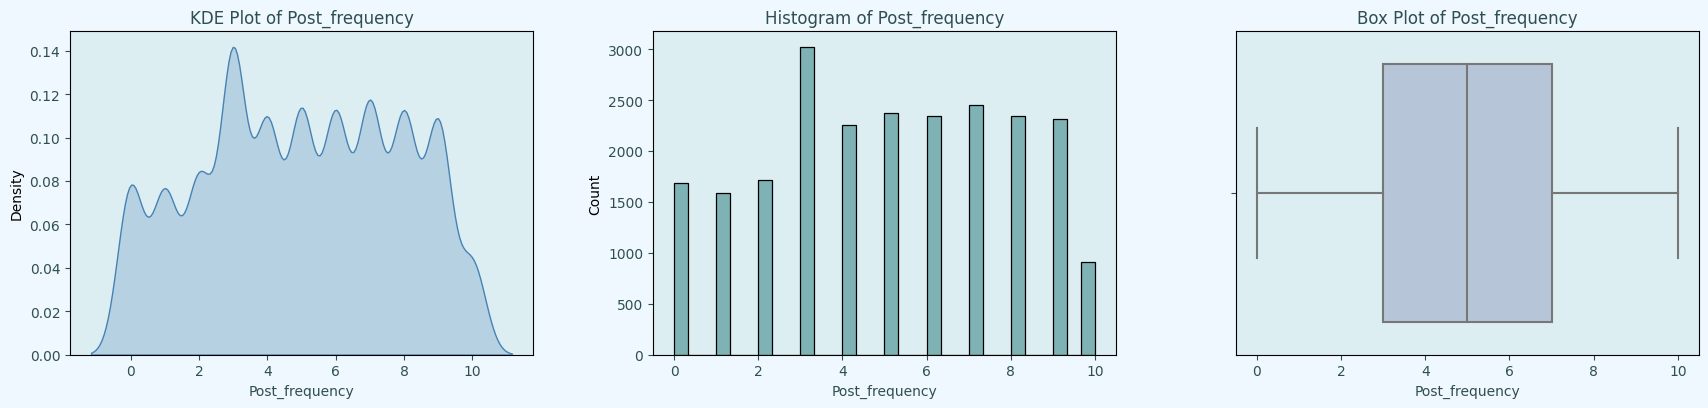

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose the column
col = 'Post_frequency'  # Replace with your column name
numeric_col = df[col]

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#F0F8FF')  # Alice Blue (Frosty background)

# KDE Plot
axes[0].set_facecolor('#DCEEF2')  # Icy gray-blue
sns.kdeplot(numeric_col, ax=axes[0], color='#4682B4', fill=True)  # Steel Blue
axes[0].set_title(f"KDE Plot of {col}", color='#2F4F4F')  # Dark Slate Gray
axes[0].set_xlabel(col, color='#2F4F4F')
axes[0].tick_params(colors='#2F4F4F')

# Histogram
axes[1].set_facecolor('#DCEEF2')
sns.histplot(numeric_col, ax=axes[1], bins=30, color='#5F9EA0')  # Cadet Blue
axes[1].set_title(f"Histogram of {col}", color='#2F4F4F')
axes[1].set_xlabel(col, color='#2F4F4F')
axes[1].tick_params(colors='#2F4F4F')

# Box Plot
axes[2].set_facecolor('#DCEEF2')
sns.boxplot(x=numeric_col, ax=axes[2], color='#B0C4DE')  # Light Steel Blue
axes[2].set_title(f"Box Plot of {col}", color='#2F4F4F')
axes[2].set_xlabel(col, color='#2F4F4F')
axes[2].tick_params(colors='#2F4F4F')

# Layout
plt.tight_layout(pad=4)
plt.show()


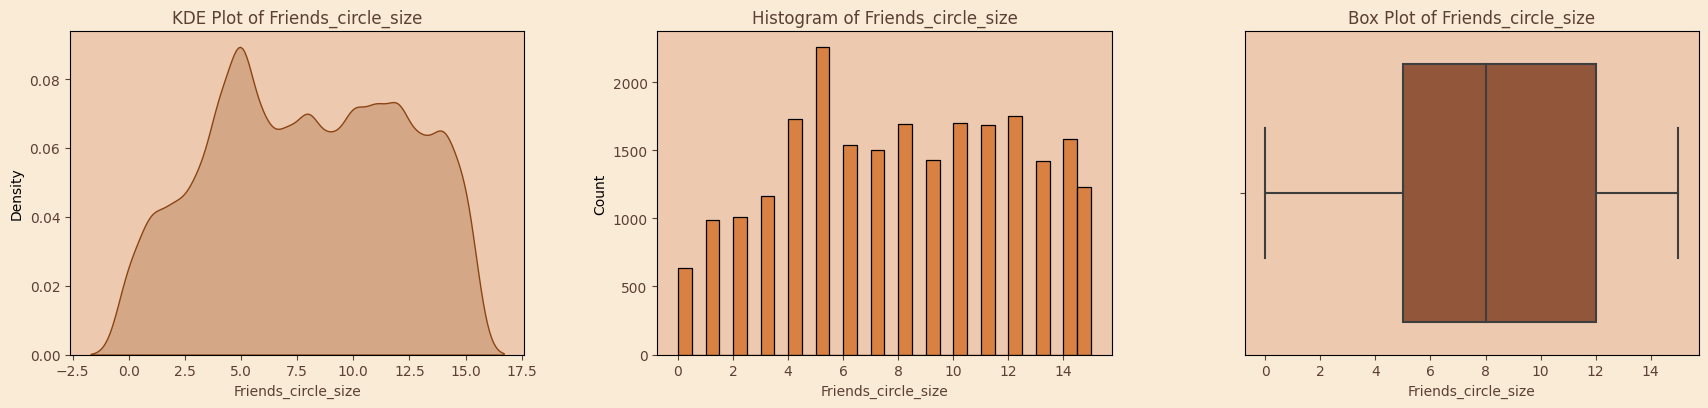

In [15]:
# Choose the column
col = 'Friends_circle_size'  # Replace with your column name
numeric_col = df[col]

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FAEBD7')  # Antique White (Desert background)

# KDE Plot
axes[0].set_facecolor('#EDC9AF')  # Desert Sand
sns.kdeplot(numeric_col, ax=axes[0], color='#8B4513', fill=True)  # Saddle Brown
axes[0].set_title(f"KDE Plot of {col}", color='#5C4033')  # Dark Earth
axes[0].set_xlabel(col, color='#5C4033')
axes[0].tick_params(colors='#5C4033')

# Histogram
axes[1].set_facecolor('#EDC9AF')
sns.histplot(numeric_col, ax=axes[1], bins=30, color='#D2691E')  # Chocolate
axes[1].set_title(f"Histogram of {col}", color='#5C4033')
axes[1].set_xlabel(col, color='#5C4033')
axes[1].tick_params(colors='#5C4033')

# Box Plot
axes[2].set_facecolor('#EDC9AF')
sns.boxplot(x=numeric_col, ax=axes[2], color='#A0522D')  # Sienna
axes[2].set_title(f"Box Plot of {col}", color='#5C4033')
axes[2].set_xlabel(col, color='#5C4033')
axes[2].tick_params(colors='#5C4033')

# Layout
plt.tight_layout(pad=4)
plt.show()



In [16]:
# For all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
skew_values = numeric_cols.skew()

# Display skewness
print(skew_values.sort_values(ascending=False))


Time_spent_Alone           1.138587
id                         0.000000
Friends_circle_size       -0.055067
Post_frequency            -0.062806
Social_event_attendance   -0.232995
Going_outside             -0.361797
is_train                  -1.154708
dtype: float64


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Imputing Missing Values in numerical Columns based on skewness</div>

In [17]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Impute missing values based on skewness
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        skew = df[col].skew()
        if abs(skew) > 1:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Encoding of catagorical columns</div>

In [18]:
manual_mappings = {
    'Stage_fear': {'Yes':1,'No':1},
    'Personality': {'Introvert': 0,'Extrovert': 2},
    'Drained_after_socializing': {'Yes':1,'No':1}
}

for col, mapping in manual_mappings.items():
    df[col] = df[col].map(mapping)


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Feature Engeniering</div>

In [19]:
# Feature Engineering
df['Social_Activity'] = df['Post_frequency'] + df['Social_event_attendance']
df['Alone_vs_Outside'] = df['Time_spent_Alone'] / (df['Going_outside'] + 1)
df['Alone_Activity_Ratio'] = df['Time_spent_Alone'] / (df['Social_event_attendance'] + 1)
df['Outdoor_Social_Score'] = (df['Going_outside'] + df['Social_event_attendance']) / 2
df['Engagement_Level'] = df['Friends_circle_size'] + df['Post_frequency']
df['Introvert_Indicator'] = (df['Time_spent_Alone'] > df['Friends_circle_size']).astype(int)
df['Drained_Social_Ratio'] = df['Drained_after_socializing'] / (df['Social_event_attendance'] + 1)
df['Activity_Complexity'] = df['Social_event_attendance'] * df['Going_outside'] * df['Post_frequency']
df['Friend_Social_Balance'] = df['Friends_circle_size'] / (df['Social_event_attendance'] + 1)
df['Isolation_Index'] = df['Time_spent_Alone'] / (df['Friends_circle_size'] + 1)
df['Engagement_Ratio'] = df['Post_frequency'] / (df['Drained_after_socializing'] + 1)
df['Social_Fatigue_Index'] = df['Drained_after_socializing'] / (df['Going_outside'] + df['Social_event_attendance'] + 1)
df['Composite_Activity_Score'] = (df['Going_outside'] + df['Post_frequency'] + df['Friends_circle_size']) / 3
df['Anti_Social_Index'] = (df['Time_spent_Alone'] + df['Drained_after_socializing']) / (df['Friends_circle_size'] + 1)


In [20]:
df['Social_Effort_Score'] = df['Social_event_attendance'] + df['Drained_after_socializing']
df['Alone_to_Social_Ratio'] = df['Time_spent_Alone'] / (df['Social_event_attendance'] + df['Going_outside'] + 1)
df['Engagement_Per_Friend'] = (df['Post_frequency'] + 1) / (df['Friends_circle_size'] + 1)
df['Socializing_Efficiency'] = df['Social_event_attendance'] / (df['Drained_after_socializing'] + 1)
df['Outdoor_Engagement_Index'] = df['Going_outside'] * df['Post_frequency']
df['Social_Recovery_Index'] = df['Drained_after_socializing'] / (df['Time_spent_Alone'] + 1)
df['Friend_Dependence_Ratio'] = df['Friends_circle_size'] / (df['Time_spent_Alone'] + 1)
df['Personal_Space_Index'] = df['Time_spent_Alone'] / (df['Post_frequency'] + 1)
df['Balanced_Lifestyle_Score'] = (df['Going_outside'] + df['Time_spent_Alone']) / 2
df['Energy_Use_Index'] = (df['Social_event_attendance'] + df['Going_outside']) / (df['Drained_after_socializing'] + 1)


# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Corelation</div>

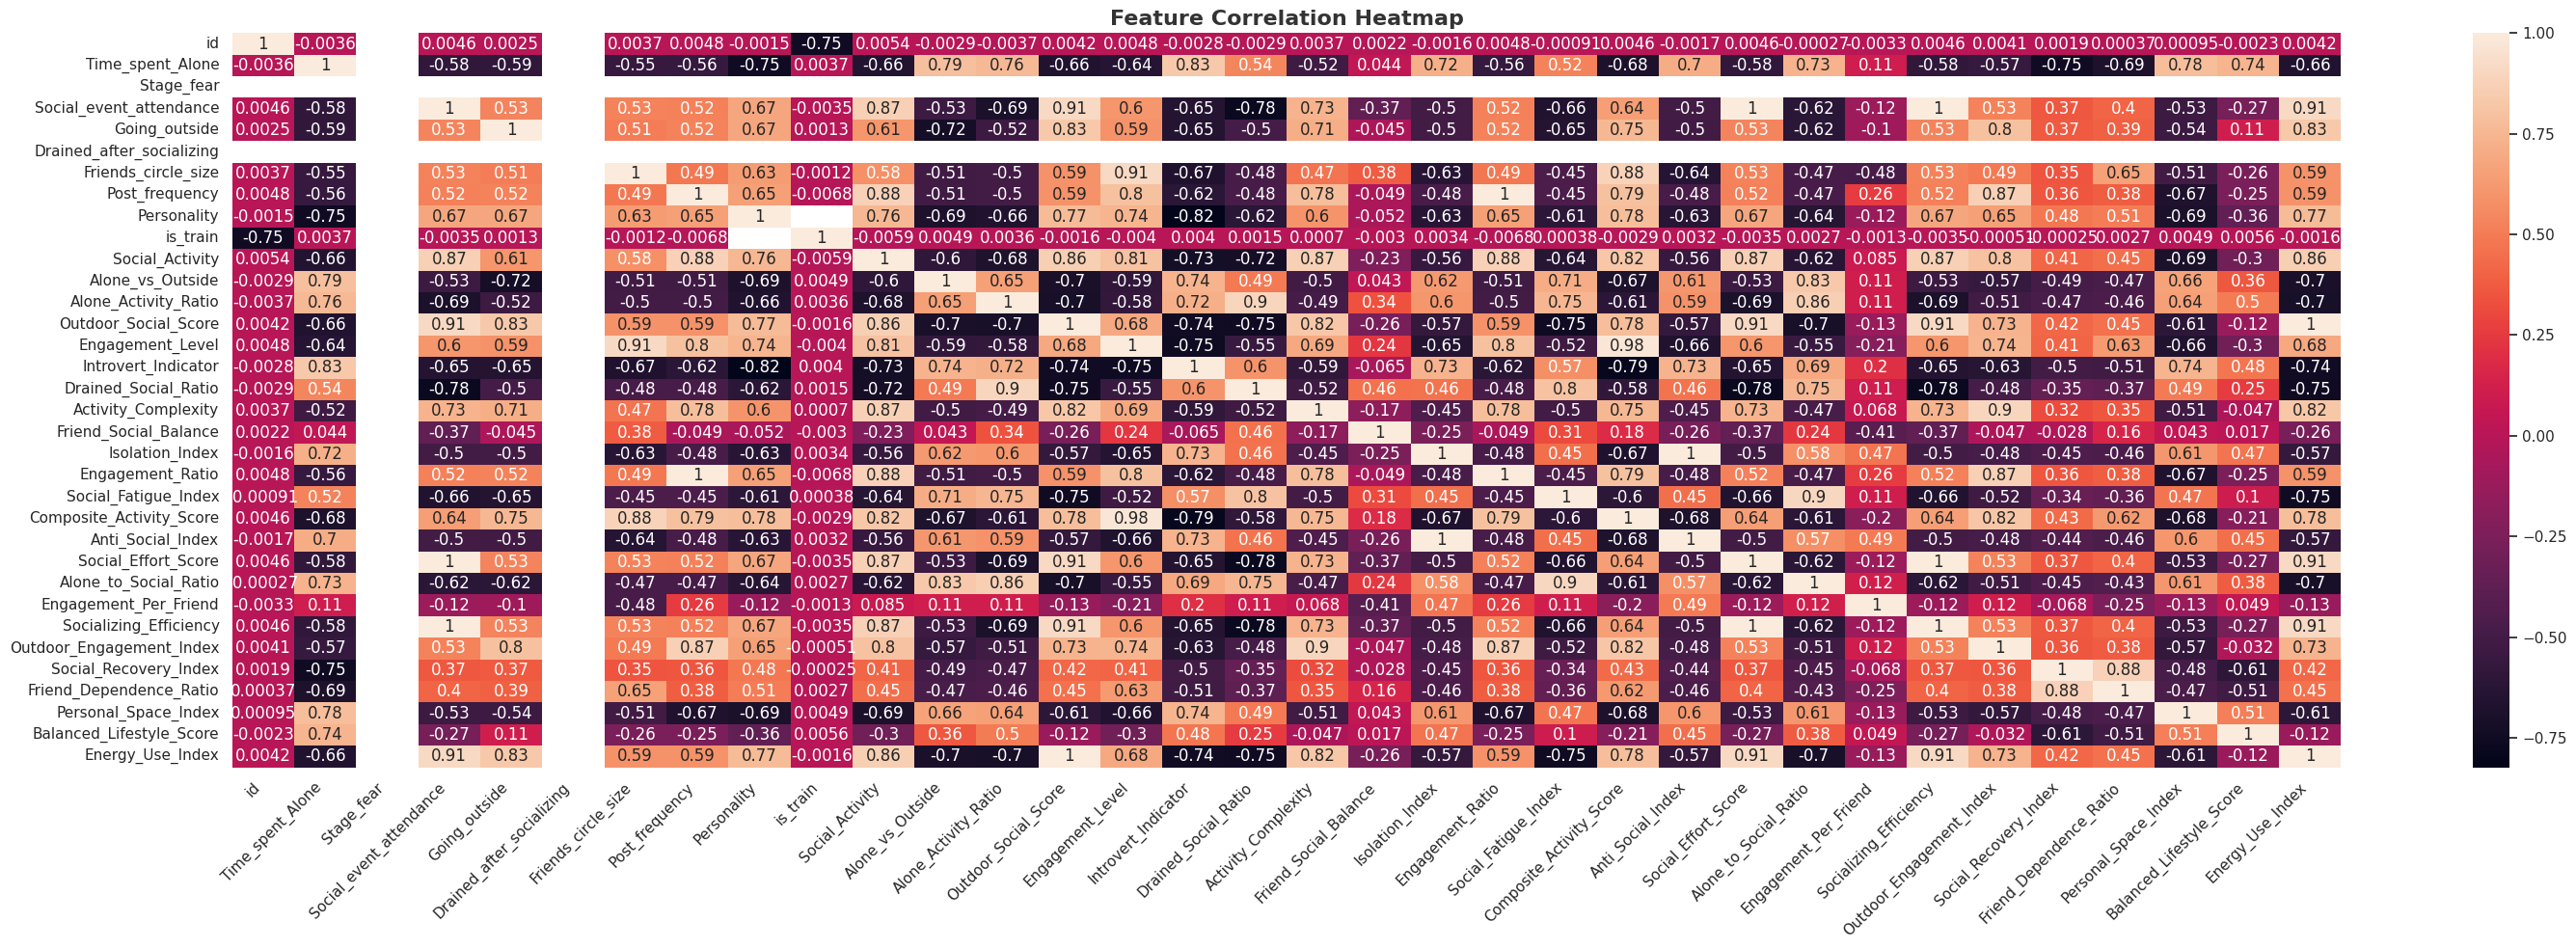

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Set up the figure
plt.figure(figsize=(30, 10))
sns.set(style="white")


# Draw the heatmap
sns.heatmap(
df.corr(),annot=True
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold', color='#333333')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:
df.drop(columns=['Friend_Social_Balance'], inplace=True)
df.drop(columns=['id'], inplace=True)

# <div style="color:#2d83ed; font-family: 'Segoe UI'; text-align:center; border-left:5px solid green; border-right:5px solid green; padding-left:10px; background-color:#F8F9F9; padding:10px; border-radius:5px;font-weight: bold">Splitting Back and Traing the models</div>

In [23]:
# Split back into train and test
train_df = df[df['is_train'] == 1].drop(columns=['is_train'])
test_df = df[df['is_train'] == 0].drop(columns=['is_train'])


In [24]:
# Separate features and target
X = train_df.drop(columns=['Personality'])  # replace 'Target' with actual label column
y = train_df['Personality']


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.9668
Random Forest: Accuracy = 0.9625
SVM: Accuracy = 0.9646
Naive Bayes: Accuracy = 0.9671
Decision Tree: Accuracy = 0.9309


In [26]:
# ✅ Select Random Forest as the best model manually (or choose based on best accuracy)
best_model = GaussianNB() 
best_model.fit(X, y)  # Train on full data

# Prepare test data
test_df = test_df.drop(columns=['Personality'], errors='ignore')
test_df = test_df[X.columns]  # align columns with training data

# Predict on test set
test_preds = best_model.predict(test_df)

# Create submission
submission = pd.DataFrame({
    'id': sample_sub['id'],
    'Personality': test_preds
})

# Map labels to strings if needed
submission['Personality'] = submission['Personality'].map({0.0: 'Introvert', 2.0: 'Extrovert'})

# Save submission file
submission.to_csv("submission.csv", index=False)
print("✅ Random Forest submission saved as submission.csv")


✅ Random Forest submission saved as submission.csv


In [27]:
submission

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert
...,...,...
6170,24694,Extrovert
6171,24695,Introvert
6172,24696,Extrovert
6173,24697,Extrovert
